<a href="https://colab.research.google.com/github/nuhuynhh/AAI2026/blob/main/AdOptimizationAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Scaling Note:**
To run this ad optimization agent reliably in the cloud, the workflow could be scheduled daily using a cloud service such as Google Cloud Run, AWS Lambda, or a cron-triggered notebook/script. Logs should be written to a central location for monitoring budget changes, performance metrics, and failures. Retry logic should be added in case the CSV or API data source fails to load. Cost controls should include daily budget caps, thresholds for unusual spend changes, and alerts when projected CPA rises above a set limit.


Part 1: Load the Data and Display first 5 rows

In [2]:
import pandas as pd
import numpy as np

# Change this when your CSV is available
csv_path = "AdOptimSampleData.csv"

df = pd.read_csv(csv_path)
df.head()

,Date,Channel,Spend,Impressions,Clicks,Conversions
0,3/1/26,Search,100,5000,250,20
1,3/1/26,Social,100,7000,200,12
2,3/1/26,Display,100,9000,150,8
3,3/2/26,Search,110,5200,260,22
4,3/2/26,Social,95,7100,190,11


In [3]:
# Standardize column names just in case
df.columns = [col.strip() for col in df.columns]

# Convert date column
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%y")
# Sort for safer day-by-day processing
df = df.sort_values(["Date", "Channel"]).reset_index(drop=True)

df.head()

,Date,Channel,Spend,Impressions,Clicks,Conversions
0,2026-03-01,Display,100,9000,150,8
1,2026-03-01,Search,100,5000,250,20
2,2026-03-01,Social,100,7000,200,12
3,2026-03-02,Display,95,8800,145,7
4,2026-03-02,Search,110,5200,260,22


Part 2: Create Performace Metrics

In [4]:
# Performance metrics
df["ctr"] = np.where(df["Impressions"] > 0, df["Clicks"] / df["Impressions"], 0)
df["cvr"] = np.where(df["Clicks"] > 0, df["Conversions"] / df["Clicks"], 0)
df["cpa"] = np.where(df["Conversions"] > 0, df["Spend"] / df["Conversions"], np.nan)

# Agent settings
channels = sorted(df["Channel"].unique().tolist()) if "Channel" in df.columns else ["Search", "Social", "Display"]
total_daily_budget = 300

# Guardrails
min_share = 0.20          # each channel keeps at least 20%
shift_pct = 0.10          # move 10% toward best performer
max_daily_change = 0.20   # no channel changes more than 20 percentage points in one day

Part 3: Define Agent Logic

In [5]:
def rebalance_to_sum_one(allocation_dict):
    """Normalize shares so total = 1.0."""
    total = sum(allocation_dict.values())
    if total == 0:
        n = len(allocation_dict)
        return {k: 1/n for k in allocation_dict}
    return {k: v / total for k, v in allocation_dict.items()}

def apply_guardrails(prev_alloc, proposed_alloc, min_share=0.20, max_daily_change=0.20):
    """
    Apply:
    1) minimum share floor
    2) max daily change cap
    3) re-normalization to 100%
    """
    adjusted = proposed_alloc.copy()
    guardrail_notes = []

    # Cap daily change per channel
    for ch in adjusted:
        delta = adjusted[ch] - prev_alloc[ch]
        if delta > max_daily_change:
            adjusted[ch] = prev_alloc[ch] + max_daily_change
            guardrail_notes.append(f"{ch} increase capped at +{max_daily_change:.0%}")
        elif delta < -max_daily_change:
            adjusted[ch] = prev_alloc[ch] - max_daily_change
            guardrail_notes.append(f"{ch} decrease capped at -{max_daily_change:.0%}")

    adjusted = rebalance_to_sum_one(adjusted)

    # Enforce minimum share
    for ch in adjusted:
        if adjusted[ch] < min_share:
            deficit = min_share - adjusted[ch]
            adjusted[ch] = min_share

            # take deficit from the highest-allocated channel above the floor
            donors = sorted(
                [c for c in adjusted if c != ch and adjusted[c] > min_share],
                key=lambda x: adjusted[x],
                reverse=True
            )

            for donor in donors:
                available = adjusted[donor] - min_share
                take = min(available, deficit)
                adjusted[donor] -= take
                deficit -= take
                if deficit <= 1e-9:
                    break

            guardrail_notes.append(f"{ch} raised to minimum share of {min_share:.0%}")

    adjusted = rebalance_to_sum_one(adjusted)
    return adjusted, guardrail_notes


def run_agent(df, channels, total_daily_budget=300, shift_pct=0.10, min_share=0.20, max_daily_change=0.20):
    """
    Uses today's performance to decide tomorrow's budget.
    """
    unique_days = sorted(df["Date"].unique())

    # Start with equal split
    current_alloc = {ch: 1 / len(channels) for ch in channels}

    logs = []
    allocations = []

    for i, day in enumerate(unique_days):
        day_data = df[df["Date"] == day].copy()

        # Save today's budget allocation in dollars
        allocation_row = {"Date": pd.to_datetime(day)}
        for ch in channels:
            allocation_row[ch] = round(current_alloc[ch] * total_daily_budget, 2)
        allocations.append(allocation_row)

        # No next-day decision after last day
        if i == len(unique_days) - 1:
            break

        # Performance summary for the day
        perf = (
            day_data.groupby("Channel")[["ctr", "cvr", "cpa", "Conversions", "Clicks", "Spend"]]
            .mean()
            .reindex(channels)
        )

        # Fill missing channels safely
        perf["ctr"] = perf["ctr"].fillna(0)
        perf["cvr"] = perf["cvr"].fillna(0)
        perf["Conversions"] = perf["Conversions"].fillna(0)
        perf["Clicks"] = perf["Clicks"].fillna(0)
        perf["Spend"] = perf["Spend"].fillna(0)

        # Choose winner by CVR; tie-breaker by conversions
        best_channel = perf.sort_values(["cvr", "Conversions"], ascending=False).index[0]

        proposed_alloc = current_alloc.copy()
        proposed_alloc[best_channel] += shift_pct

        others = [ch for ch in channels if ch != best_channel]
        reduction = shift_pct / len(others)

        for ch in others:
            proposed_alloc[ch] -= reduction

        proposed_alloc = rebalance_to_sum_one(proposed_alloc)

        # Apply guardrails
        final_alloc, guardrail_notes = apply_guardrails(
            current_alloc,
            proposed_alloc,
            min_share=min_share,
            max_daily_change=max_daily_change
        )

        # Log decision
        logs.append({
            "decision_date": pd.to_datetime(unique_days[i + 1]),
            "based_on_date": pd.to_datetime(day),
            "best_channel": best_channel,
            "best_cvr": round(float(perf.loc[best_channel, "cvr"]), 4),
            "best_ctr": round(float(perf.loc[best_channel, "ctr"]), 4),
            "prev_allocation": current_alloc.copy(),
            "new_allocation": final_alloc.copy(),
            "reason": f"{best_channel} increased by {shift_pct:.0%} proposal due to highest CVR on {pd.to_datetime(day).date()}",
            "guardrails_applied": "; ".join(guardrail_notes) if guardrail_notes else "None"
        })

        current_alloc = final_alloc.copy()

    allocations_df = pd.DataFrame(allocations)
    logs_df = pd.DataFrame(logs)

    return allocations_df, logs_df


allocations_df, logs_df = run_agent(
    df=df,
    channels=channels,
    total_daily_budget=total_daily_budget,
    shift_pct=shift_pct,
    min_share=min_share,
    max_daily_change=max_daily_change
)

print("Daily budget allocations:")
display(allocations_df)

print("\nDecision logs:")
display(logs_df)

Daily budget allocations:


,Date,Display,Search,Social
0,2026-03-01,100.0,100.0,100.0
1,2026-03-02,85.0,130.0,85.0
2,2026-03-03,70.0,160.0,70.0
3,2026-03-04,60.0,180.0,60.0
4,2026-03-05,60.0,150.0,90.0
5,2026-03-06,90.0,135.0,75.0
6,2026-03-07,75.0,165.0,60.0
7,2026-03-08,60.0,150.0,90.0
8,2026-03-09,90.0,135.0,75.0
9,2026-03-10,75.0,165.0,60.0



Decision logs:


,decision_date,based_on_date,best_channel,best_cvr,best_ctr,prev_allocation,new_allocation,reason,guardrails_applied
0,2026-03-02,2026-03-01,Search,0.0800,0.0500,"{'Display': 0.3333333333333333, 'Search': 0.33...","{'Display': 0.2833333333333333, 'Search': 0.43...",Search increased by 10% proposal due to highes...,None
1,2026-03-03,2026-03-02,Search,0.0846,0.0500,"{'Display': 0.2833333333333333, 'Search': 0.43...","{'Display': 0.23333333333333334, 'Search': 0.5...",Search increased by 10% proposal due to highes...,None
2,2026-03-04,2026-03-03,Search,0.0800,0.0500,"{'Display': 0.23333333333333334, 'Search': 0.5...","{'Display': 0.2, 'Search': 0.6000000000000001,...",Search increased by 10% proposal due to highes...,Display raised to minimum share of 20%; Social...
3,2026-03-05,2026-03-04,Social,0.0600,0.0286,"{'Display': 0.2, 'Search': 0.6000000000000001,...","{'Display': 0.2, 'Search': 0.5, 'Social': 0.30...",Social increased by 10% proposal due to highes...,Display raised to minimum share of 20%
4,2026-03-06,2026-03-05,Display,0.0533,0.0167,"{'Display': 0.2, 'Search': 0.5, 'Social': 0.30...","{'Display': 0.30000000000000004, 'Search': 0.4...",Display increased by 10% proposal due to highe...,None
5,2026-03-07,2026-03-06,Search,0.0846,0.0500,"{'Display': 0.30000000000000004, 'Search': 0.4...","{'Display': 0.25, 'Search': 0.5499999999999999...",Search increased by 10% proposal due to highes...,None
6,2026-03-08,2026-03-07,Social,0.0579,0.0268,"{'Display': 0.25, 'Search': 0.5499999999999999...","{'Display': 0.2, 'Search': 0.49999999999999994...",Social increased by 10% proposal due to highes...,None
7,2026-03-09,2026-03-08,Display,0.0483,0.0165,"{'Display': 0.2, 'Search': 0.49999999999999994...","{'Display': 0.30000000000000004, 'Search': 0.4...",Display increased by 10% proposal due to highe...,None
8,2026-03-10,2026-03-09,Search,0.0800,0.0500,"{'Display': 0.30000000000000004, 'Search': 0.4...","{'Display': 0.25000000000000006, 'Search': 0.5...",Search increased by 10% proposal due to highes...,None
9,2026-03-11,2026-03-10,Social,0.0600,0.0286,"{'Display': 0.25000000000000006, 'Search': 0.5...","{'Display': 0.20000000000000007, 'Search': 0.4...",Social increased by 10% proposal due to highes...,None


Part 4: Log Rationale

In [6]:
# Cleaner view of the rationale log
rationale_view = logs_df[[
    "decision_date",
    "based_on_date",
    "best_channel",
    "best_cvr",
    "best_ctr",
    "reason",
    "guardrails_applied"
]].copy()

display(rationale_view)

,decision_date,based_on_date,best_channel,best_cvr,best_ctr,reason,guardrails_applied
0,2026-03-02,2026-03-01,Search,0.0800,0.0500,Search increased by 10% proposal due to highes...,None
1,2026-03-03,2026-03-02,Search,0.0846,0.0500,Search increased by 10% proposal due to highes...,None
2,2026-03-04,2026-03-03,Search,0.0800,0.0500,Search increased by 10% proposal due to highes...,Display raised to minimum share of 20%; Social...
3,2026-03-05,2026-03-04,Social,0.0600,0.0286,Social increased by 10% proposal due to highes...,Display raised to minimum share of 20%
4,2026-03-06,2026-03-05,Display,0.0533,0.0167,Display increased by 10% proposal due to highe...,None
5,2026-03-07,2026-03-06,Search,0.0846,0.0500,Search increased by 10% proposal due to highes...,None
6,2026-03-08,2026-03-07,Social,0.0579,0.0268,Social increased by 10% proposal due to highes...,None
7,2026-03-09,2026-03-08,Display,0.0483,0.0165,Display increased by 10% proposal due to highe...,None
8,2026-03-10,2026-03-09,Search,0.0800,0.0500,Search increased by 10% proposal due to highes...,None
9,2026-03-11,2026-03-10,Social,0.0600,0.0286,Social increased by 10% proposal due to highes...,None


Part 5: Evaluate Performance

In [7]:
def build_budget_lookup(allocations_df, channels):
    """
    Turns allocations_df into a lookup dict:
    {date: {channel: allocated_budget}}
    """
    lookup = {}
    for _, row in allocations_df.iterrows():
        day = pd.to_datetime(row["Date"])
        lookup[day] = {ch: row[ch] for ch in channels}
    return lookup

# Estimate performance under the agent allocation
# using spend ratio as a lightweight offline approximation
def evaluate_strategy(df, allocations_df, channels, total_daily_budget=300):
    """
    Simple offline evaluation:
    - Estimate conversions by scaling observed conversions with allocated spend / observed spend
    - Estimate clicks the same way
    This is a lightweight approximation for class purposes.
    """
    alloc_lookup = build_budget_lookup(allocations_df, channels)

    records = []

    for _, row in df.iterrows():
        day = pd.to_datetime(row["Date"])
        ch = row["Channel"]

        observed_spend = row["Spend"]
        observed_clicks = row["Clicks"]
        observed_conversions = row["Conversions"]
        observed_impressions = row["Impressions"]

        allocated_spend = alloc_lookup.get(day, {}).get(ch, total_daily_budget / len(channels))

        if observed_spend > 0:
            spend_ratio = allocated_spend / observed_spend
        else:
            spend_ratio = 0

        est_clicks = observed_clicks * spend_ratio
        est_conversions = observed_conversions * spend_ratio
        est_impressions = observed_impressions * spend_ratio

        records.append({
            "Date": day,
            "Channel": ch,
            "allocated_spend": allocated_spend,
            "estimated_clicks": est_clicks,
            "estimated_conversions": est_conversions,
            "estimated_impressions": est_impressions
        })

    result_df = pd.DataFrame(records)

    total_spend = result_df["allocated_spend"].sum()
    total_clicks = result_df["estimated_clicks"].sum()
    total_conversions = result_df["estimated_conversions"].sum()
    total_impressions = result_df["estimated_impressions"].sum()

    summary = {
        "total_spend": round(total_spend, 2),
        "total_clicks": round(total_clicks, 2),
        "total_conversions": round(total_conversions, 2),
        "avg_ctr": round(total_clicks / total_impressions, 4) if total_impressions > 0 else 0,
        "avg_cpa": round(total_spend / total_conversions, 2) if total_conversions > 0 else np.nan
    }

    return result_df, summary


def create_equal_split_allocations(df, channels, total_daily_budget=300):
    """Baseline: equal split every day."""
    # Get all unique days in chronological order
    unique_days = sorted(df["Date"].unique())
    rows = []

    for day in unique_days:
        row = {"Date": pd.to_datetime(day)}
        for ch in channels:
            row[ch] = round(total_daily_budget / len(channels), 2)
        rows.append(row)

    return pd.DataFrame(rows)


# Baseline allocations
baseline_allocations_df = create_equal_split_allocations(df, channels, total_daily_budget)

# Evaluate agent and baseline
agent_eval_df, agent_summary = evaluate_strategy(df, allocations_df, channels, total_daily_budget)
baseline_eval_df, baseline_summary = evaluate_strategy(df, baseline_allocations_df, channels, total_daily_budget)

comparison_df = pd.DataFrame([
    {"strategy": "Agent", **agent_summary},
    {"strategy": "Baseline Equal Split", **baseline_summary}
])

display(comparison_df)

# Quick text explanation
agent_conv = agent_summary["total_conversions"]
base_conv = baseline_summary["total_conversions"]
agent_cpa = agent_summary["avg_cpa"]
base_cpa = baseline_summary["avg_cpa"]

print("Result summary:")
if agent_conv > base_conv:
    print(f"- The agent outperformed the equal-split baseline on estimated conversions ({agent_conv} vs {base_conv}).")
elif agent_conv < base_conv:
    print(f"- The agent underperformed the equal-split baseline on estimated conversions ({agent_conv} vs {base_conv}).")
else:
    print(f"- The agent matched the equal-split baseline on estimated conversions ({agent_conv}).")

print(f"- Agent avg CPA: {agent_cpa}")
print(f"- Baseline avg CPA: {base_cpa}")
print("- Trade-off: the agent concentrates more budget on high-performing channels while keeping minimum spend on others for continued learning.")

,strategy,total_spend,total_clicks,total_conversions,avg_ctr,avg_cpa
0,Agent,2605.0,5597.52,402.98,0.0331,6.46
1,Baseline Equal Split,2900.0,5812.99,392.02,0.0288,7.40


Result summary:
- The agent outperformed the equal-split baseline on estimated conversions (402.98 vs 392.02).
- Agent avg CPA: 6.46
- Baseline avg CPA: 7.4
- Trade-off: the agent concentrates more budget on high-performing channels while keeping minimum spend on others for continued learning.


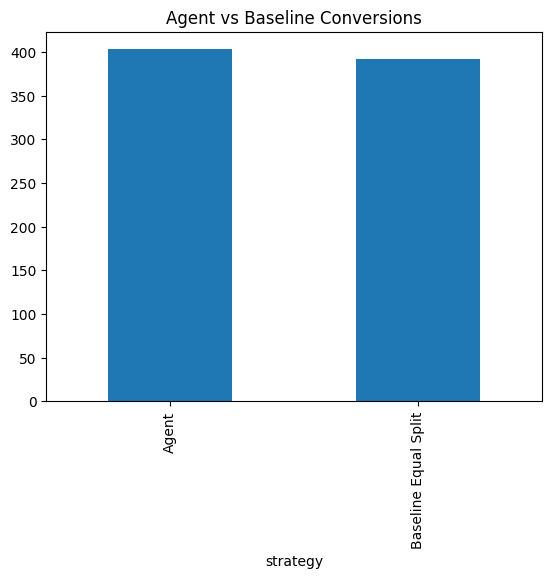

In [10]:
import matplotlib.pyplot as plt

comparison_df.set_index("strategy")["total_conversions"].plot(kind="bar")
plt.title("Agent vs Baseline Conversions")
plt.show()